# Question 1 <!--{-}-->  

We can model the resultant force in terms of the states ***q*** and
***p*** and their derivatives. Since $f = ma$:

$$m\ddot{\mathbf{q}} = - \gamma\left( \dot{\mathbf{q}} - \beta\begin{bmatrix}
 - \frac{\sqrt{2}}{2} & - \frac{\sqrt{2}}{2} \\
\frac{\sqrt{2}}{2} & - \frac{\sqrt{2}}{2}
\end{bmatrix}\mathbf{q} \right) + \mathbf{u}$$

Since the desired result is a $1^{st}$ order state-space model,
$\ddot{\mathbf{q}}$ needs to be converted to something different.

The resultant force can also be expressed as the rate of change of
momentum, i.e., $\dot{\mathbf{p}}$.

$$\dot{\mathbf{p}} = - \gamma\left( \dot{\mathbf{q}} - \beta\begin{bmatrix}
 - \frac{\sqrt{2}}{2} & - \frac{\sqrt{2}}{2} \\
\frac{\sqrt{2}}{2} & - \frac{\sqrt{2}}{2}
\end{bmatrix}\mathbf{q} \right) + \mathbf{u}$$

We can also express $\dot{\mathbf{q}}$ in terms of ***p***. A scale
factor of $\frac{1}{m}$ needs to be applied since momentum is a function
of mass.

$$\dot{\mathbf{p}} = - \gamma\left( \frac{\mathbf{p}}{m} \right) + \gamma\beta\begin{bmatrix}
 - \frac{\sqrt{2}}{2} & - \frac{\sqrt{2}}{2} \\
\frac{\sqrt{2}}{2} & - \frac{\sqrt{2}}{2}
\end{bmatrix}\mathbf{q + u}$$

$$\dot{\mathbf{q}} = \frac{\mathbf{p}}{m}$$

It is now possible to convert this to state-space:

$$\left\lbrack \begin{array}{r}
\begin{matrix}
{\dot{q}}_{x} \\
{\dot{q}}_{y} \\
{\dot{p}}_{x} \\
{\dot{p}}_{y}
\end{matrix}
\end{array} \right\rbrack = \begin{bmatrix}
0 & 0 & \frac{1}{m} & 0 \\
0 & 0 & 0 & \frac{1}{m} \\
 - \frac{\gamma\beta\sqrt{2}}{2} & - \frac{\gamma\beta\sqrt{2}}{2} & - \frac{\gamma}{m} & 0 \\
\frac{\gamma\beta\sqrt{2}}{2} & - \frac{\gamma\beta\sqrt{2}}{2} & 0 & - \frac{\gamma}{m}
\end{bmatrix}\left\lbrack \begin{array}{r}
\begin{matrix}
q_{x} \\
q_{y} \\
p_{x} \\
p_{y}
\end{matrix}
\end{array} \right\rbrack + \begin{bmatrix}
0 & 0 \\
0 & 0 \\
1 & 0 \\
0 & 1
\end{bmatrix}\begin{bmatrix}
u_{x} \\
u_{y}
\end{bmatrix}$$

# Question 2

To implement the implicit Euler method for solving this state-space ODE, the following equation can be used:

$$\mathbf{X}\left( t_{i} \right) = \left( I_{4} - \Delta t_{i}A \right)^{- 1}\left( \mathbf{X}\left( t_{i - 1} \right) + \Delta t_{i}Bu \right)$$

Note that $\mathbf{X} = \left\lbrack \begin{array}{r}
\begin{matrix}
q_{x} \\
q_{y} \\
p_{x} \\
p_{y}
\end{matrix}
\end{array} \right\rbrack$.

Question 1: The magnitude of the distance between the drone and the origin is 1.995110 metres at 15.8 seconds.


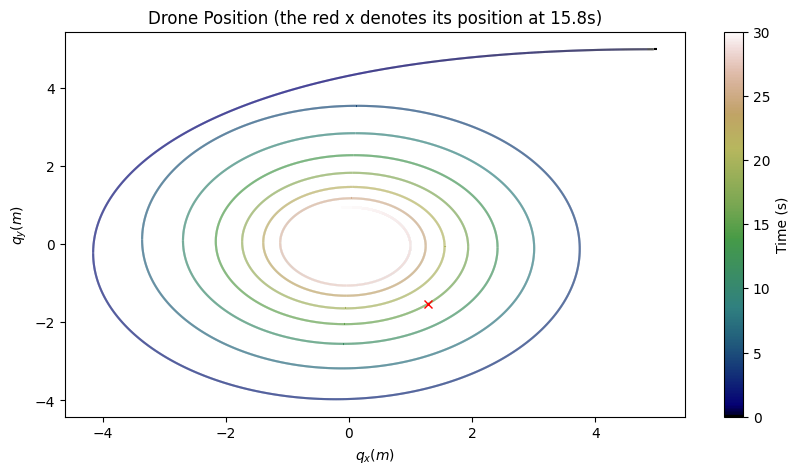

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import scipy as sp
from matplotlib.collections import LineCollection

np.random.seed(2110409)
plt.rcParams['figure.figsize'] = [10, 5]

m = 1.5
gamma = 2.5
omega = 2

A = np.array([[0, 0, 1/m, 0], 
              [0, 0, 0, 1/m],
              [((-gamma*omega*2**0.5)/2), ((-gamma*omega*2**0.5)/2), -gamma/m, 0],
              [((gamma*omega*2**0.5)/2), ((-gamma*omega*2**0.5)/2), 0, -gamma/m]])
B = np.array([[0, 0], [0, 0], [1, 0], [0, 1]])
uEuler = 0*np.array([1, 1])

x0 = np.array([5, 5, 0, 0])
dt = 0.001
T = np.arange(0.0, 30.0 + dt, dt)

X = np.zeros((4,len(T)))
X[:, 0] = x0

for i in range(len(T))[1:]:
    X[:,i] = (np.linalg.solve(np.eye(4) - dt*A, X[:,i-1] + dt*B@uEuler))

fig, ax = plt.subplots()
points = np.array([X[0,:], X[1,:]]).T.reshape(-1,1,2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
normT = plt.Normalize(T[0], T[-1])
lC = LineCollection(segments, cmap="gist_earth", norm=normT)
lC.set_array(T)
line = ax.add_collection(lC)
fig.colorbar(line, ax=ax, label="Time (s)")
# the matplotlib documentation for the multicolored line helped me for Q1's plot

ax.plot(X[0, T == 15.8], X[1, T == 15.8], color="red", marker = "x")
ax.set_title("Drone Position (the red x denotes its position at 15.8s)"); 
ax.set_xlabel("$q_{x} (m)$"); ax.set_ylabel("$q_{y} (m)$");
dist = (X[0, T == 15.8]**2 + X[1, T == 15.8]**2)**0.5
print("Question 1: The magnitude of the distance between the drone and the origin is %f metres at 15.8 seconds."  %dist[0])

After plotting the two positions against each other, we can verify that the drone follows a spiral path towards the origin. It also drifts within two metres of the origin at around 15.8 seconds. This distance is computed as the distance between two points.


# Question 3
The Kalman filter relies on five equations, all of which will be
detailed below.

$${\widehat{x}}_{i} = A_{d}{\widehat{x}}_{i - 1} + B_{d}u_{i}\ (1)$$

$\widehat{x}$ is the estimate, $A_{d}$ is the state transition matrix,
and $B_{d}$ is the control matrix.

$A_{d}$ and $B_{d}$ are the discretised matrices of A and B from the
state-space model. To calculate $A_{d}$, we can use the matrix
exponential $e^{\Delta tA}$. To calculate $B_{d}$, we can use
the formula $A^{-1}\left( A_{d} - I_{4} \right)B$.

$$P_{i} = A_{d}P_{i - 1}A_{d}^{'} + Q\ (2)$$

$P_{i}$ is the state covariance matrix and Q is the process noise.
However, in our model this will be 0.

In the update step, there are three equations:

$$K = P_{i}H^{'}\left( HP_{i}H^{'} + R \right)^{- 1}\ (3)$$

K is the Kalman gain, and since the position is the only thing we are observing, the observation matrix H will be:

$$\begin{bmatrix}
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0
\end{bmatrix}$$

Finally, the last two equations are:

$${\widehat{x}}_{i} = {\widehat{x}}_{i} + K^{'}\left( y_{i} - H{\widehat{x}}_{i} \right)\ (4)$$

$$P_{i} = \left( I_{4} - KH \right)P_{i}\ (5)$$

These equations of the Kalman filter were based on [this Wikipedia page.](https://en.wikipedia.org/wiki/Kalman_filter#Details)
The discretisation of the state-space model was based on [this Wikipedia page](https://en.wikipedia.org/wiki/Discretization#Discretization_of_linear_state_space_models), where we assume the input force is constant between time steps.

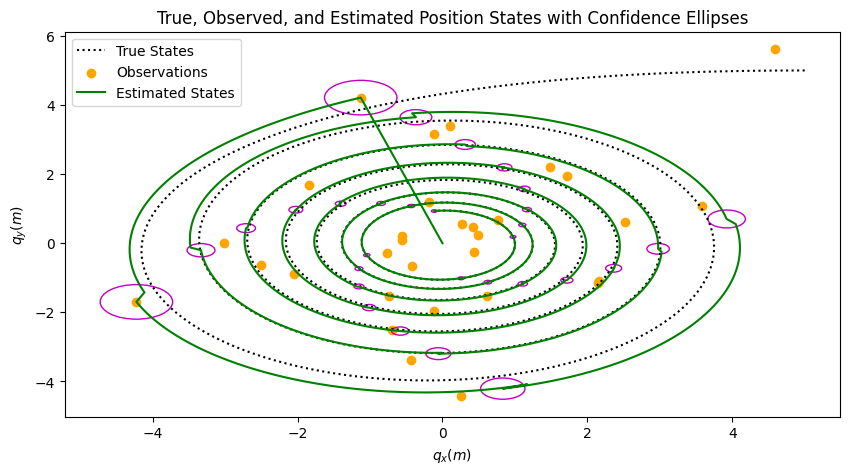

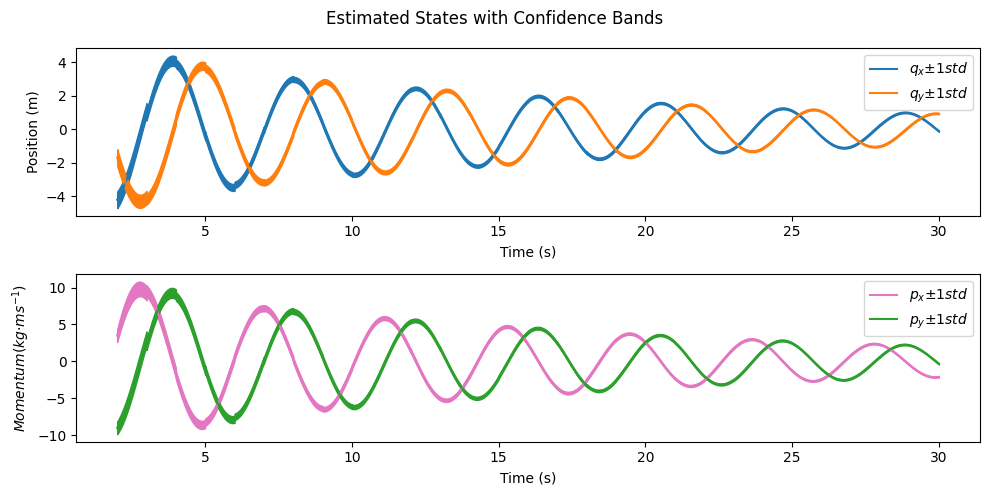

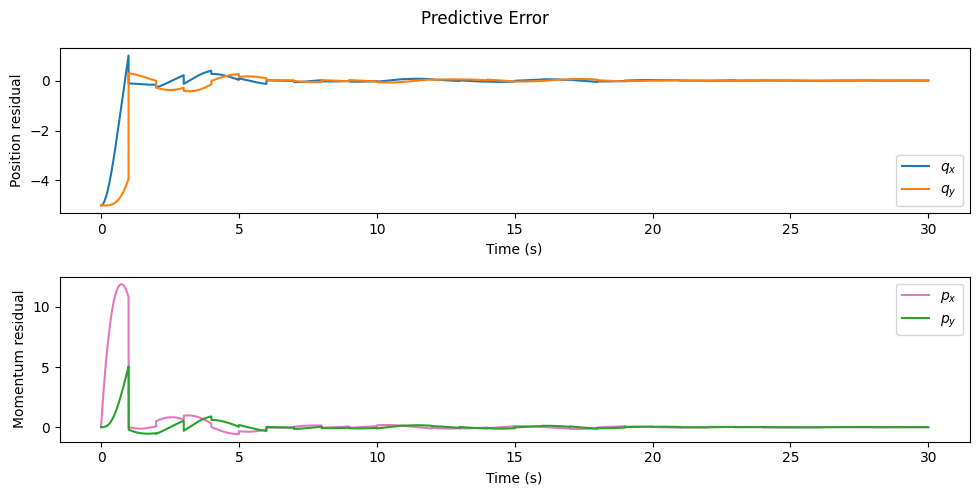

In [2]:
H = np.array([[1, 0, 0, 0], [0, 1, 0, 0]])
R = np.eye(2)*0.5**2
# set up initial values
y = np.zeros((2, len(T)))
X_true = X
y[:,0] = H@X_true[:,0] + 0.5*np.random.normal(size=(2,)) # 1st observation

X_hat_0 = 0*np.array([1, 1, 0, 0])
X_hat = np.zeros((4, len(T)))
X_hat[:,0] = X_hat_0
P = np.zeros((len(T), 4, 4)) # 3D array to store each state covariance matrix
P[0] = np.eye(4)*1e6 # agnostic initial state covariance matrix
Fi = sp.linalg.expm(dt*A) # discretisation of A using the time step
Bi = np.linalg.inv(A)@(Fi-np.eye(4))@B # discretisation of B using Fi
uKalman = 0*np.array([1, 1])

intTime = np.round(T) == T
for i in range(len(T))[1:]:
    # forecast/prediction step
    X_hat[:,i] = Fi@X_hat[:,i-1] + Bi@uKalman
    P[i] = Fi@P[i-1]@Fi.T
    
    if intTime[i] == True:
        # analysis/update step which is done only at integer time
        y[:,i] = H@X_true[:,i] + 0.5*np.random.normal(size=(2,))
        K = P[i]@H.T@np.linalg.inv(H@P[i]@H.T + R)
        X_hat[:,i] = X_hat[:,i] + K@(y[:,i] - H@X_hat[:,i])
        P[i] = (np.eye(4)-K@H)@P[i]
    
y = y[:, intTime] # removes all the unnecessary padding between observations 
fig1, ax1 = plt.subplots()
ax1.plot(X_true[0,:], X_true[1,:], ":", color="black",  label="True States")
ax1.scatter(y[0,:], y[1,:], color="orange", label="Observations")
ax1.plot(X_hat[0,:], X_hat[1,:], color="green", label="Estimated States")

PPos = P[:, :2, :2]
for i in range(len(T))[1000:]: # the first second is excluded since it would heavily distort the axes
    if intTime[i] == True:
        meanPos = X_hat[0:2,i]
        eigValsPos, _ = np.linalg.eig(PPos[i,:,:])
        # The off diagonals in the covariance matrices are essentially zero. Since the leading diagonals are equal, we can use an angle of 0 for the ellipse.
        # also, since eigValsPos[0] = eigValsPos[1], the angle does not matter since the ellipse plotted will be a circle
        anglePos = 0
        # The calculated radii below correspond to a +-1 std. They are scaled up by 2 since Ellipse needs 2*r in its calculation
        confidenceRegionPos = Ellipse(xy=meanPos, width=2*np.sqrt(eigValsPos[0]), height=2*np.sqrt(eigValsPos[1]), angle=anglePos, edgecolor="m", facecolor="none")
        ax1.add_patch(confidenceRegionPos)
        # the ellipsis formula is based on this website: https://cookierobotics.com/007/
    
ax1.legend()
ax1.set_title("True, Observed, and Estimated Position States with Confidence Ellipses"); ax1.set_xlabel("$q_{x} (m)$"); ax1.set_ylabel("$q_{y} (m)$");

PMom = P[:, 2:, 2:]
# we only plot the confidence bands after two seconds; otherwise the plot will be distorted 
fig2, ax2 = plt.subplots(nrows=2, ncols=1)
ax2[0].fill_between(T[2000:], X_hat[0,2000:] + np.sqrt(PPos[2000:,0,0]), X_hat[0,2000:] - np.sqrt(PPos[2000:,0,0]), color="tab:blue")
ax2[0].plot(T[2000:], X_hat[0,2000:], color="tab:blue", label="$q_{x} ± 1 std$")
ax2[0].fill_between(T[2000:], X_hat[1,2000:] + np.sqrt(PPos[2000:,1,1]), X_hat[1,2000:] - np.sqrt(PPos[2000:,1,1]), color="tab:orange")
ax2[0].plot(T[2000:], X_hat[1,2000:], color="tab:orange", label="$q_{y} ± 1 std$")
ax2[1].fill_between(T[2000:], X_hat[2,2000:] + np.sqrt(PMom[2000:,0,0]), X_hat[2,2000:] - np.sqrt(PMom[2000:,0,0]), color="tab:pink")
ax2[1].plot(T[2000:], X_hat[2,2000:], color="tab:pink", label="$p_{x} ± 1 std$")
ax2[1].fill_between(T[2000:], X_hat[3,2000:] + np.sqrt(PMom[2000:,1,1]), X_hat[3,2000:] - np.sqrt(PMom[2000:,1,1]), color="tab:green")
ax2[1].plot(T[2000:], X_hat[3,2000:], color="tab:green", label="$p_{y} ± 1 std$")
ax2[0].legend(); ax2[1].legend();
ax2[0].set_xlabel("Time (s)"); ax2[0].set_ylabel("Position (m)");
ax2[1].set_xlabel("Time (s)"); ax2[1].set_ylabel("$Momentum (kg⋅ms^{-1})$");
fig2.suptitle("Estimated States with Confidence Bands")
fig2.tight_layout()

# the predictive error can be plotted for all of the time values
predictiveError = X_hat-X
predictiveErrorDist = predictiveError[[0,1],:]; predictiveErrorMom = predictiveError[[2,3],:];
fig3, ax3 = plt.subplots(nrows=2, ncols=1)
ax3[0].plot(T, predictiveErrorDist[0,:], label="$q_{x}$")
ax3[0].plot(T, predictiveErrorDist[1,:], label="$q_{y}$")
ax3[0].set_xlabel("Time (s)"); ax3[0].set_ylabel("Position residual")
ax3[1].plot(T, predictiveErrorMom[0,:], label="$p_{x}$", color="tab:pink")
ax3[1].plot(T, predictiveErrorMom[1,:], label="$p_{y}$", color="tab:green")
ax3[0].legend(); ax3[1].legend();
ax3[1].set_xlabel("Time (s)"); ax3[1].set_ylabel("Momentum residual")
fig3.suptitle("Predictive Error"); fig3.tight_layout();

In the first figure, the estimated position states are plotted against each other as in question 1, along with the true and observed states. Confidence ellipses have been plotted also, but only at integer times.
Note that the first confidence ellipse has been ignored as it would heavily distort the axes.
The Kalman filter performs well, with the estimated states closely tracking the true states, even though our initial predicted state was incorrect.

The confidence ellipses/bands start off large, however as time preogresses the Kalman filter gets more confident and the regions become smaller. We can see this also with the predictive error of the system, where the error is initially large but decreases significantly.

# Question 4
To implement a PD control mechanism for the drone using the estimated states (position only), the error (difference between the desired position and the current estimated position) needs to be considered.
The proportional control is a simple scale factor $K_{P}$ of the error.
The derivative control looks at the derivative of the error with respect to time. This can be scaled with another value, $K_{D}$.

After some testing, values of 300 and 350 were chosen for $K_{P}$ in the $x$ and $y$ directions respectively. $K_{D}$ was set to 0.01.
These values brought the drone the closest to the desired position. The code was ran a few times (without the student ID seed) to ensure the final values did not exceed a given tolerance (explained further below).

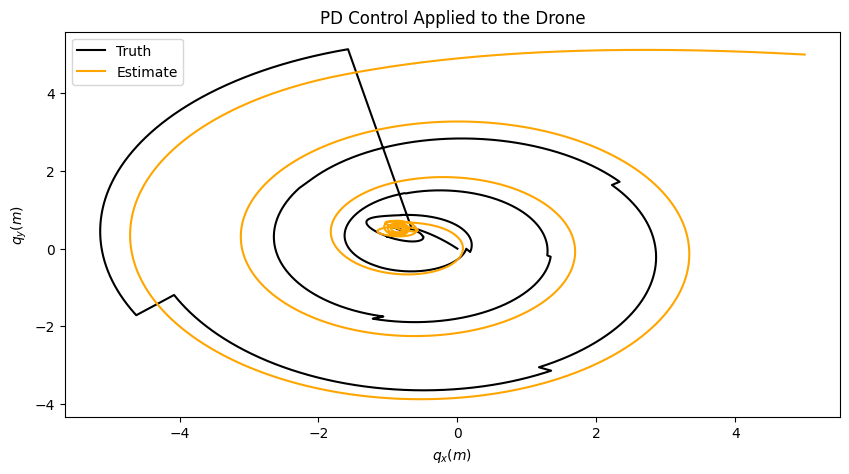

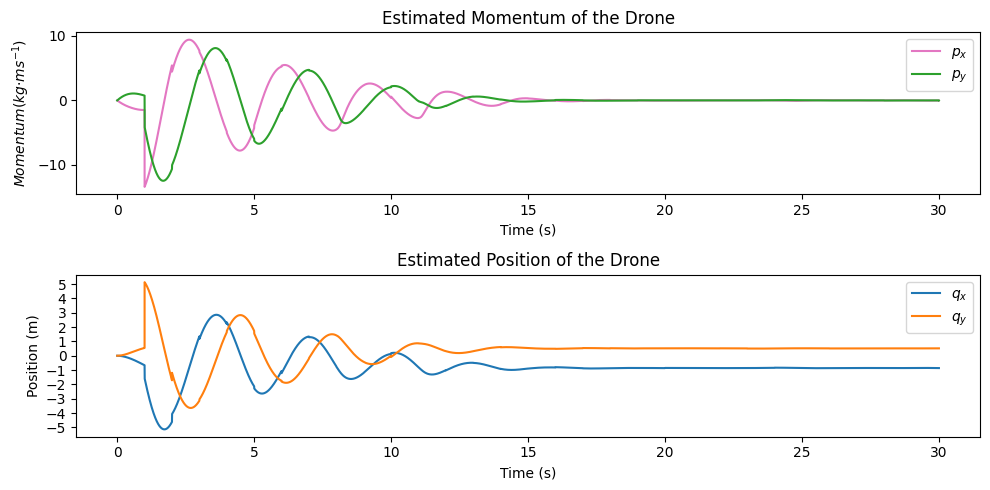

In [3]:
def implicitEuler(XInit, uInput, Amat, Bmat):
    # refactor Q1 code to solve only the next state
    dt = 0.001
    trueStates = np.zeros((4,2))
    trueStates[:,0] = XInit
    trueStates[:,1] = (np.linalg.solve(np.eye(4) - dt*Amat, trueStates[:,0] + dt*Bmat@uInput))
    return trueStates

def kalmanFilter(Amat, Bmat):
    # The kalman filter remains largely the same with the exception of the PD control.
    # We base the PD control from the estimations which are based on the true states.
    # The true states will change based on the control force, hence the reason for modifying the euler code.
    
    dt = 0.001
    Time = np.arange(0.0, 30.0 + dt, dt)
    H = np.array([[1, 0, 0, 0], [0, 1, 0, 0]])
    R = np.eye(2)*0.5**2
    
    XTrue = np.zeros((4, len(Time)))
    XTrue[:,0] = np.array([5.0, 5.0, 0.0, 0.0])
    obs = np.zeros((2, len(Time)))
    obs[:,0] = H@XTrue[:,0] + 0.5*np.random.normal(size=(2,))
    
    XPredicted = np.zeros((4, len(Time)))
    XInit = 0*np.array([1, 1, 0, 0])
    XPredicted[:,0] = XInit
    
    P = np.zeros((len(Time), 4, 4))
    P[0] = np.eye(4)*1e6
    Fi = sp.linalg.expm(dt*Amat)
    Bi = np.linalg.inv(Amat)@(Fi-np.eye(4))@Bmat
    
    qStar = np.array([-1, 1])
    err = np.zeros((2, len(Time)))
    err[:,0] = qStar-XInit[1:2]
    uInput = np.zeros((2, len(Time)))
    
    for i in range(len(Time))[1:]:
        eulerStates = implicitEuler(XTrue[:,i-1], uInput[:,i-1], Amat, Bmat) # call the modified euler code
        XTrue[:,i] = eulerStates[:,-1]
        
        XPredicted[:,i] = Fi@XPredicted[:,i-1] + Bi@uInput[:,i-1]
        uInput[:,i], err[:,i] = PD_Controller(qStar, XPredicted[[0, 1], i], err[:, i-1]) # control relies only on estimate
        P[i] = Fi@P[i-1]@Fi.T
        
        if round(Time[i]) == Time[i]:
            obs[:,i] = H@XTrue[:,i] + 0.5*np.random.normal(size=(2,))
            K = P[i]@H.T@np.linalg.inv(H@P[i]@H.T + R)
            XPredicted[:,i] = XPredicted[:,i] + K@(obs[:,i] - H@XPredicted[:,i])
            P[i] = (np.eye(4)-K@H)@P[i]
        
    return XPredicted, XTrue, obs, err, uInput
        
def PD_Controller(finalPos, estimatedPos, prevError):
    error = finalPos-estimatedPos
    derivative = (error-prevError)/dt
    KpX = 300; KpY = 350
    KdX = 0.01; KdY = 0.01
    
    uControl = np.zeros((2,))
    uControl[0] = KpX*error[0] + KdX*derivative[0]
    uControl[1] = KpY*error[1] + KdY*derivative[1]
    uMagnitude = (uControl[0]**2 + uControl[1]**2)**0.5
    if uMagnitude >= 5:
        scale = 5/uMagnitude
        uControl = uControl*scale
        
    return uControl, error

XHat, XTrue, _, _, _ = kalmanFilter(A,B)
fig4, ax4 = plt.subplots()
ax4.plot(XHat[0,:], XHat[1,:], color="black", label="Truth")
ax4.plot(XTrue[0,:], XTrue[1,:], color="orange", label="Estimate")
ax4.legend()
ax4.set_title("PD Control Applied to the Drone")
ax4.set_xlabel("$q_{x} (m)$"); ax4.set_ylabel("$q_{y} (m)$")

fig5, ax5 = plt.subplots(nrows=2, ncols=1)
ax5[0].plot(T, XHat[2,:], label="$p_{x}$", color="tab:pink")
ax5[0].plot(T, XHat[3,:], label="$p_{y}$", color="tab:green")
ax5[0].set_title("Estimated Momentum of the Drone")
ax5[0].legend()
ax5[0].set_xlabel("Time (s)"); ax5[0].set_ylabel("$Momentum (kg⋅ms^{-1})$");

ax5[1].plot(T, XHat[0,:], label="$q_{x}$")
ax5[1].plot(T, XHat[1,:], label="$q_{y}$")
ax5[1].set_title("Estimated Position of the Drone")
ax5[1].legend()
ax5[1].set_xlabel("Time (s)"); ax5[1].set_ylabel("Position (m)");
yticks5 = list(range(-5, 6))
ax5[1].set_yticks(yticks5);
fig5.tight_layout()

The first plot is made to verify that the estimated states follow the true states as expected, which they do.
To check whether the drone comes to rest, its momentum can be plotted. Since the mass is constant, we can tell that its velocity goes to 0 at around halfway through the simulation, indicating that it has come to rest. At around the same time, we can see that the position of the drone has reached (within an acceptable tolerance) the desired position. Since the force constraint of 5N is quite low, the accuracy of the desired position must be given a larger than usual tolerance (&plusmn;0.5m). If the force limit is increased to around 120N, the drone can be brought to rest near the desired position within 1 decimal point accuracy.